# grid.py

Collection of classes for different grids
1- class Grid(): General class
2- class UniformCartesianGrid(Grid)
3- class UniformCylindricalGrid(Grid)

## Class UniformCartesianGrid

### 1 D grids

Note that the grid points are given as a column vector with the coordinate of every site

```python
import numpy as np
import grid as gr

grid=gr.UniformCartesianGrid(1,  limits=[0, 1], nptx=4)

print(f'{grid.x=}')
print(f'{grid.dx=}')
print(f'{grid.dV=}')
print(f'{grid.dx=}')

# grid.x=array([[0.  ],
#        [0.25],
#        [0.5 ],
#        [0.75]])
# grid.dx=[np.float64(0.25)]
# grid.dV=np.float64(0.25)
# grid.dx=[np.float64(0.25)]

```

### Selecting point is the grid

We can test the grid points againts some condition. The condidtion is given by a function. An example of it would be

```python
def filter(x):
    x_test=np.zeros(x.shape[0], dtype=bool)
    for n, ix in enumerate(x):
        x_test[n]=ix[0]>0.5 and ix[1]<0.5 
    return x_test
```

#### At definition

```python
import numpy as np
import grid as gr

def filter(x):
    x_test=np.zeros(x.shape[0], dtype=bool)
    for n, ix in enumerate(x):
        x_test[n]=ix[0]<0.5 or ix[0]>0.7
    return x_test

grid=gr.UniformCartesianGrid(1,  limits=[0, 1], nptx=4, filter=filter)

print(f'{grid.x=}')
print(f'{grid.dx=}')
print(f'{grid.dV=}')
print(f'{grid.dx=}')
print(f'{grid.inGrid=}')

# grid.x=array([[0.  ],
#        [0.25],
#        [0.5 ],
#        [0.75]])
# grid.dx=[np.float64(0.25)]
# grid.dV=np.float64(0.25)
# grid.dx=[np.float64(0.25)]
# grid.inGrid=array([ True,  True, False,  True])
```

Note that defining a filter does not change the set of grid points to only those in whic condiction is `True`. It defines, however, a new column bool vector `grid.inGrid` with the information of which point complies with the filter condition.

The set of points compliant with the consition can be found as 

```python
selected_x=grid.x[grid.inGrid]
print(f'{selected_x=}')

# selected_x=array([[0.  ],
#        [0.25],
#        [0.75]])
```

#### On the fly

At any time is possible to select points with a suplementary condition but be aware that `grid.inGrid` is not affected by the supplementary condictions

```python
import numpy as np
import grid as gr

def filter1(x):
    x_test=np.zeros(x.shape[0], dtype=bool)
    for n, ix in enumerate(x):
        x_test[n]=ix[0]<0.5 or ix[0]>0.7
    return x_test

grid=gr.UniformCartesianGrid(1,  limits=[0, 1], nptx=4) # now defined without filter

print(f'{grid.x}')
print(f'{grid.inGrid=}') # All are True as it has not been a condition

inGrid1=grid.get_inGrid(filter=filter1)

print(f'{inGrid1}  :  ix[0]<0.5 or ix[0]>0.7')

print(f'{grid.inGrid}') # grid.inGrid is not affected by the supplementary condictions

# [[0.  ]
#  [0.25]
#  [0.5 ]
#  [0.75]]
# grid.inGrid=array([ True,  True,  True,  True])
# [ True  True False  True]  :  ix[0]<0.5 or ix[0]>0.7
# [ True  True  True  True]
```
 We can define another filter and combine the results of both

```python
import numpy as np
import grid as gr

def filter2(x):
    x_test=np.zeros(x.shape[0], dtype=bool)
    for n, ix in enumerate(x):
        x_test[n]=ix[0]>0.1
    return x_test

inGrid2=grid.get_inGrid(filter=filter2)

print(f'{inGrid2}  :  ix[0]>0.1')

print(f'{grid.x[inGrid1]=}')
print(f'{inGrid1=}')
print(f'{grid.x[inGrid2]=}')
print(f'{inGrid2=}')
print(f'{grid.x[inGrid1*inGrid2]=}')
print(f'{inGrid1*inGrid2=}')

# [False  True  True  True]  :  ix[0]>0.1
# grid.x[inGrid1]=array([[0.  ],
#        [0.25],
#        [0.75]])
# inGrid1=array([ True,  True, False,  True])
# grid.x[inGrid2]=array([[0.25],
#        [0.5 ],
#        [0.75]])
# inGrid2=array([False,  True,  True,  True])
# grid.x[inGrid1*inGrid2]=array([[0.25],
#        [0.75]])
# inGrid1*inGrid2=array([False,  True, False,  True])
´´´


### Multidimensional grids

```python
import numpy as np
import grid as gr
import matplotlib.pyplot as plt

def filter(x):
    x_test=np.zeros(x.shape[0], dtype=bool)
    for n, ix in enumerate(x):
        x_test[n]=np.sqrt(ix[0]**2+ix[1]**2)<0.75
    return x_test

grid=gr.UniformCartesianGrid(2, [[-1,1],[-1,1]], origin=[0, 0.25], nptx=[4,4])

grid2=gr.UniformCartesianGrid(2, [[-1,1],[-1,1]], nptx=[100,100], filter=filter)

xcircle=grid2.x[grid2.inGrid]

fig,ax=plt.subplots(1,2, figsize=(7,3))

ax[0].scatter(grid.x[:,0],grid.x[:,1], s=20 )
ax[1].scatter(xcircle[:,0],xcircle[:,1], s=1 )
ax[1].set_xlim([-1,1])
ax[1].set_ylim([-1,1])
```

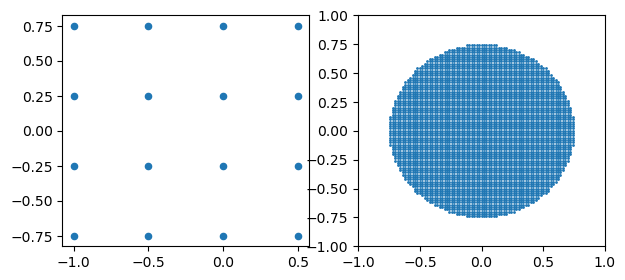


grid.dV[0]=np.float64(0.25)


(-1.0, 1.0)

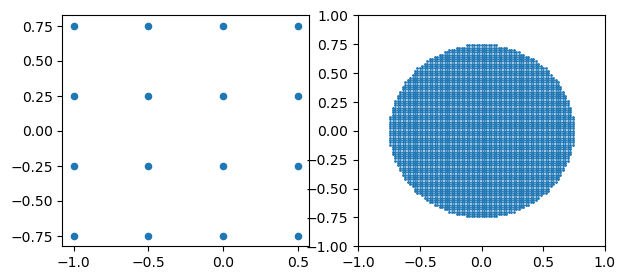

In [2]:
import numpy as np
import grid as gr
import matplotlib.pyplot as plt

def filter(x):
    x_test=np.zeros(x.shape[0], dtype=bool)
    for n, ix in enumerate(x):
        x_test[n]=np.sqrt(ix[0]**2+ix[1]**2)<0.75
    return x_test

grid=gr.UniformCartesianGrid(2, [[-1,1],[-1,1]], origin=[0, 0.25], nptx=[4,4])

print(f'{grid.dV[0]=}')

grid2=gr.UniformCartesianGrid(2, [[-1,1],[-1,1]], nptx=[100,100], filter=filter)

xcircle=grid2.x[grid2.inGrid]

fig,ax=plt.subplots(1,2, figsize=(7,3))

ax[0].scatter(grid.x[:,0],grid.x[:,1], s=20 )
ax[1].scatter(xcircle[:,0],xcircle[:,1], s=1 )
ax[1].set_xlim([-1,1])
ax[1].set_ylim([-1,1])

## Class UniformCylindricalGrid

### 1 D grids

A cylindrical 1D grid has only the $\rho$ dimension. No the differential of volume corresponds to $\rho d \rho$, therefore is a colum vector with the same length as the grid.

```python
import numpy as np
import grid as gr

grid=gr.UniformCylindricalGrid(1,  limits=[0, 1], nptx=4)

print(f'{grid.x=}')
print(f'{grid.dx=}')
print(f'{grid.dV=}') # Column vector
print(f'{grid.dx=}')

# grid.x=array([[0.  ],
#        [0.25],
#        [0.5 ],
#        [0.75]])
# grid.dx=[np.float64(0.25)]
# grid.dV=array([[0.    ],
#        [0.0625],
#        [0.125 ],
#        [0.1875]])
# grid.dx=[np.float64(0.25)]
```


### Multidimensional grids

We can use the method `toCartesian`to convert into a cartesian grid

```python
import numpy as np
import grid as gr
import matplotlib.pyplot as plt

grid=gr.UniformCylindricalGrid(2,  limits=[[0, 1],[0, 2*np.pi]], nptx=[20,20])

x_cart=grid.toCartesian()


fig,ax=plt.subplots(1,2, figsize=(7,3))

ax[0].scatter(grid.x[:,0],grid.x[:,1], s=20 )
ax[1].scatter(x_cart[:,0],x_cart[:,1], s=20 )
```

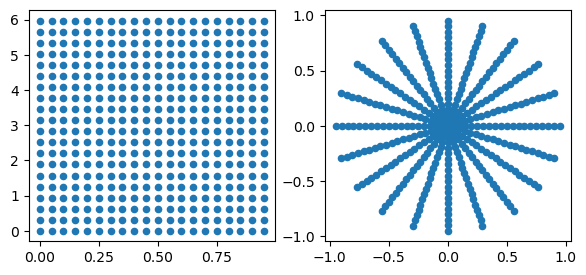



## Full example: Graphene

vprint in line: 185 --> self.vectors=array([[ 0.57735027,  1.        ],
       [ 0.57735027, -1.        ]])
graph.reciprocal_vectors=[array([0.57735027, 1.        ]), array([ 0.57735027, -1.        ])]
vprint in line: 185 --> self.vectors=array([[ 0.57735027,  1.        ],
       [ 0.57735027, -1.        ]])
vprint in line: 185 --> self.vectors=array([[ 0.57735027,  1.        ],
       [ 0.57735027, -1.        ]])
vprint in line: 185 --> self.vectors=array([[ 0.57735027,  1.        ],
       [ 0.57735027, -1.        ]])
vprint in line: 185 --> self.vectors=array([[ 0.57735027,  1.        ],
       [ 0.57735027, -1.        ]])


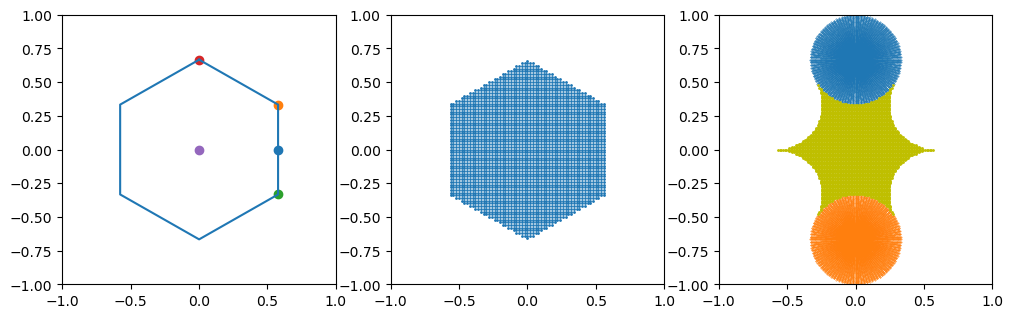

In [1]:
import numpy as np
from crystal import crystal, species, vector_in_cart
import grid as gr
import matplotlib.pyplot as plt

# create a crystal instance for graphene to have access to the geometry

graph=crystal(species['graphene'], space='reciprocal')

# find the symmetry points

print(f'{graph.reciprocal_vectors=}')

M_point=vector_in_cart(graph.parameters['reciprocal symmetry points']['M'], basis=graph.reciprocal_vectors)
K_point=vector_in_cart(graph.parameters['reciprocal symmetry points']['K'], basis=graph.reciprocal_vectors)
Kp_point=vector_in_cart(graph.parameters['reciprocal symmetry points']['Kp'], basis=graph.reciprocal_vectors)
Kpv_point=vector_in_cart(graph.parameters['reciprocal symmetry points']['Kpv'], basis=graph.reciprocal_vectors)
G_point=vector_in_cart(graph.parameters['reciprocal symmetry points']['Gamma'], basis=graph.reciprocal_vectors)




fig,ax=plt.subplots(1,3,figsize=(12,3.5))

ax[0].set_xlim(-1,1)
ax[0].set_ylim(-1,1)


ax[0].scatter(M_point[0], M_point[1])
ax[0].scatter(K_point[0], K_point[1])
ax[0].scatter(Kp_point[0], Kp_point[1])
ax[0].scatter(Kpv_point[0], Kpv_point[1])
ax[0].scatter(G_point[0], G_point[1])

phi=np.arange(0, 2*np.pi, np.pi/3)

polygon_vertices=np.column_stack((Kpv_point[1]*np.sin(phi), Kpv_point[1]*np.cos(phi)))

x=polygon_vertices[:,0]; x=np.append(x,x[0])
y=polygon_vertices[:,1]; y=np.append(y,y[0])

ax[0].plot(x,y)


###### hexagonal grid

# define the filter 

def hexfilter(x):
    def cross2d(a, b): # auxiliar funtion to define the cross product of 2D vectors
        return a[0]*b[1] - a[1]*b[0]
    phi=np.arange(0, 2*np.pi, np.pi/3)
    polygon_vertices=np.column_stack((Kpv_point[1]*np.sin(phi), Kpv_point[1]*np.cos(phi)))
    polygon_edges= np.array([polygon_vertices[i]-polygon_vertices[i-1] for i in range (6)])
    x_test=np.zeros(x.shape[0], dtype=bool)
    for n, ix in enumerate(x):
        test=[cross2d(polygon_edges[i],(ix-polygon_vertices[i]))<=1e-15 for i in range(6)]
        x_test[n]=np.all(test)
    return x_test

# define the grid

ax[1].set_xlim(-1,1)
ax[1].set_ylim(-1,1)

xlim=1
ylim=1

graph_gr= gr.UniformCartesianGrid(2,[[-xlim,xlim],[-ylim, ylim]],[100,100],filter=hexfilter)

# We can now instantiate again the graphene crystal using the grid

graph=crystal(species['graphene'], space='reciprocal', grid=graph_gr)

ax[1].scatter(graph.grid.x[graph.grid.inGrid][:,0],graph.grid.x[graph.grid.inGrid][:,1], s=1)


###### Polar grids surrounding the K points

K_point=vector_in_cart(graph.parameters['reciprocal symmetry points']['K'], basis=graph.reciprocal_vectors)

radius=np.sqrt((K_point-M_point)[0]**2+(K_point-M_point)[1]**2) # computes the norm 

graph_Kp_grid= gr.UniformCylindricalGrid(2,[[0,radius],[0, 2*np.pi]],[100,100], cartesian=True, offset=Kpv_point)

graph=crystal(species['graphene'], space='reciprocal', grid=graph_Kp_grid)

ax[2].scatter(graph.grid.x[:,0],graph.grid.x[:,1], s=0.1)
ax[2].set_xlim(-1,1)
ax[2].set_ylim(-1,1)

K_point=Kpv_point*(1,-1)

graph_K_grid= gr.UniformCylindricalGrid(2,[[0,radius],[0, 2*np.pi]],[100,100], cartesian=True, offset=K_point)

graph=crystal(species['graphene'], space='reciprocal', grid=graph_K_grid)

ax[2].scatter(graph.grid.x[:,0],graph.grid.x[:,1], s=0.1)

###### Complementary mesh

def Complementaryfilter(x):
    def distance(a, b): # auxiliar funtion to define the cross product of 2D vectors
        v=b-a
        return np.sqrt(v[0]**2+v[1]**2)
    phi=np.arange(0, 2*np.pi, np.pi/3)
    ylim=Kpv_point[1]
    polygon_vertices=np.column_stack((ylim*np.sin(phi), ylim*np.cos(phi)))
    x_test=np.zeros(x.shape[0], dtype=bool)
    for n, ix in enumerate(x):
        test=[distance(polygon_vertices[i],ix)>radius for i in range(6)]
        x_test[n]=np.all(test)
    return x_test

xlim=M_point[0]
ylim=M_point[0]*np.cos(np.pi/6)

graph_gr= gr.UniformCartesianGrid(2,[[-xlim,xlim],[-ylim, ylim]],[100,100],filter=Complementaryfilter)

graph=crystal(species['graphene'], space='reciprocal', grid=graph_gr)


ax[2].scatter(graph.grid.x[graph.grid.inGrid][:,0],graph.grid.x[graph.grid.inGrid][:,1], s=1, color='y')

# Class FonGrid



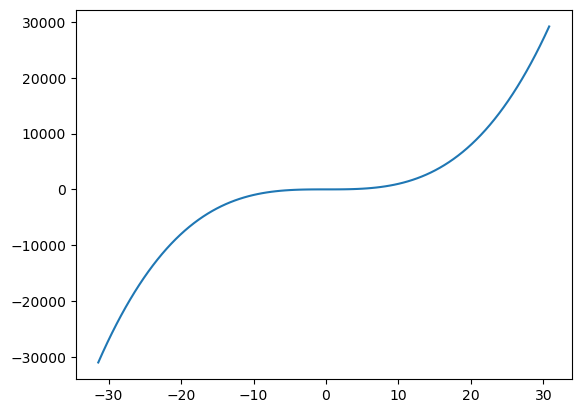

In [3]:
import numpy as np
from grid import UniformCartesianGrid, FonGrid
import matplotlib.pyplot as plt

# generate a 1D grid

gr_t=UniformCartesianGrid(1, [-10*np.pi, 10*np.pi], 100)

# callable for the function
def f(x, **parameters):
    pow=parameters['pow']
    return x**pow

# create the FonGrid object
parameters={'pow': 3}

f_test=FonGrid(f, gr_t, **parameters)


plt.plot(gr_t.x, f_test.val)

